In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & evaluation tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('cumulative.csv')

df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [2]:
#Filter out 'CANDIDATE'
df = df[df['koi_disposition'] != 'CANDIDATE']

#Map 'CONFIRMED' to 1 (True Exoplanet) and 'FALSE POSITIVE' to 0 (False Alarm)
df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

columns_to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 
    'koi_disposition', 'koi_pdisposition', 'koi_tce_delivname'
]
df = df.drop(columns=columns_to_drop)

#handle missing values
threshold = len(df) * 0.60
df = df.dropna(axis=1, thresh=threshold)
df = df.dropna(axis=0)
df = df.select_dtypes(exclude=['object'])

print(f"Data shape after cleaning: {df.shape}")
print(df['target'].value_counts())

Data shape after cleaning: (6031, 42)
target
0    3763
1    2268
Name: count, dtype: int64


In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
target
0    3010
1    1814
Name: count, dtype: int64


In [4]:
#apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(y_train_resampled.value_counts())

After SMOTE:
target
1    3010
0    3010
Name: count, dtype: int64


In [5]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f" {model_name} ")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

# 1.Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest (Base)")

# 2.XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)
evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost (Base)")

# 3.Neural Network (MLPClassifier)
nn_model = MLPClassifier(random_state=42, max_iter=500)
nn_model.fit(X_train_resampled, y_train_resampled)
evaluate_model(nn_model, X_test_scaled, y_test, "Simple Neural Network (Base)")

 Random Forest (Base) 
Accuracy:  0.9925
Precision: 1.0000
Recall:    0.9802
F1-Score:  0.9900

 XGBoost (Base) 
Accuracy:  0.9950
Precision: 0.9956
Recall:    0.9912
F1-Score:  0.9934

 Simple Neural Network (Base) 
Accuracy:  0.9925
Precision: 0.9978
Recall:    0.9824
F1-Score:  0.9900



In [6]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# setup RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10, # no. of parameter settings that are sampled
    cv=3,    
    scoring='f1', # maximize the F1 Score
    verbose=2,
    random_state=42,
    n_jobs=-1  
)

# Fit in random search model
print("Searching for the best parameters. This might take a minute...")
rf_random.fit(X_train_resampled, y_train_resampled)

# Get the best model
best_rf = rf_random.best_estimator_

# Evaluate the optimized model
print("\nBest Parameters found:", rf_random.best_params_)
evaluate_model(best_rf, X_test_scaled, y_test, "Random Forest (Optimized)")

Searching for the best parameters. This might take a minute...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
 Random Forest (Optimized) 
Accuracy:  0.9925
Precision: 1.0000
Recall:    0.9802
F1-Score:  0.9900



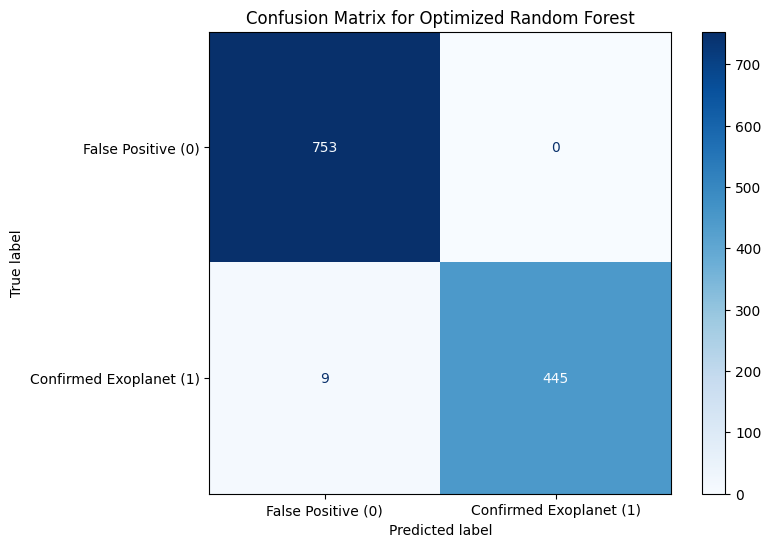

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_best = best_rf.predict(X_test_scaled)

# generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot 
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False Positive (0)', 'Confirmed Exoplanet (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Confusion Matrix for Optimized Random Forest")
plt.show()

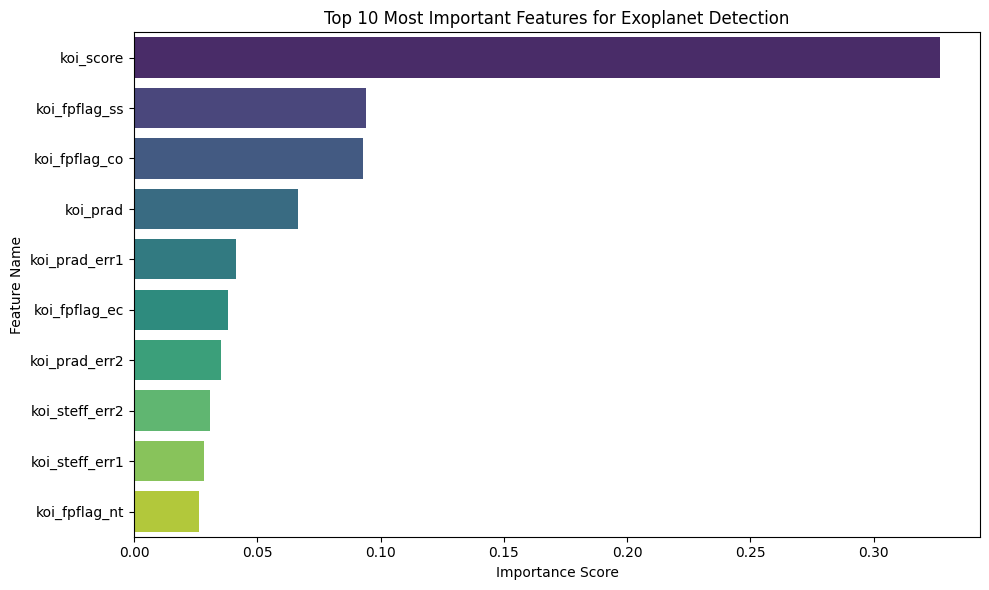

In [8]:
importances = best_rf.feature_importances_

feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# sort the features by importance (highest first) and take the top 10
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Top 10 Most Important Features for Exoplanet Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()